# 04-1. Context, State, Memory

- 핵심 기술: Context 구성, Graph State, `InMemorySaver`, `InMemoryStore`, namespace
- 최종 산출물: thread 단기 기억과 사용자 장기 기억을 연결한 LangGraph 예제

## 1. 학습목표

이 실습을 완료하면 다음을 수행할 수 있다.

1. Context, State, Memory의 정의와 생명주기 차이를 설명할 수 있다.
2. Thread별 대화 기록에서 현재 호출에 포함할 Context를 구성할 수 있다.
3. `InMemorySaver`와 `thread_id`로 단기 기억을 유지할 수 있다.
4. `InMemoryStore`와 namespace로 여러 thread가 공유하는 장기 기억을 구현할 수 있다.
5. Long-Term Memory를 저장·검색하고, 선택 학습으로 갱신·삭제(만료)를 설명할 수 있다.
6. 모든 대화를 그대로 저장했을 때 발생하는 Token 비용과 잘못된 기억 누적
   문제를 설명하고 방지할 수 있다.

## 2. 문제 상황

Agent와 여러 차례 대화를 나누다 보면 "이번 호출에 당장 필요한 정보"와
"지금 실행 중인 작업의 중간 값", "다음에 다시 만났을 때도 기억해야 할
정보"를 구분하지 못하고 전부 한 곳에 욱여넣기 쉽다. 예를 들어 지난주에
사용자가 말했던 선호 사항을 이번 대화의 Context에 대화 기록 전체와 함께
매번 다시 밀어 넣으면 Token 비용이 계속 늘어난다. 반대로 아무것도 저장해
두지 않으면 사용자가 이미 알려준 정보를 다음 대화에서 또 물어봐야 한다.
이 Notebook은 Context, State, Memory를 명확히 구분해서, 무엇을 얼마나
오래 어디에 남겨야 하는지 판단하는 기준을 세운다.

## 3. 핵심 개념

### 3.1 정의

Context는 현재 LLM 호출에 실제로 포함되는 정보다. State는 Graph의 Node가
공유하는 작업 데이터이며, Checkpointer를 연결하면 `thread_id` 범위의 단기 기억으로
이어질 수 있다. Long-Term Memory는 Store에 별도로 저장해 여러 thread에서 공유한다.

```text
Context
→ 현재 LLM 호출에 포함되는 정보

State + Checkpointer
→ 현재 Workflow 상태와 thread 단기 기억

Store
→ 여러 thread가 공유할 장기 기억
```

### 3.2 개념이 필요한 이유

이 셋을 구분하지 않으면 두 가지 문제가 생긴다. 첫째, 대화가 길어질수록
전체 기록을 Context에 그대로 밀어 넣어 Token 비용이 선형으로 증가한다.
둘째, 이번 실행에서만 유효한 중간 값(State)을 영구 보존 대상(Memory)과
섞어버리면, 오래되어 더 이상 맞지 않는 정보가 이후 판단에 계속 영향을
미친다.

### 3.3 주요 구성요소

| 구성요소 | 역할 |
|---|---|
| `THREAD_HISTORY` | 단기 기억을 설명하기 위한 Python 개념 모델 |
| `build_context()` | 대화 기록 중 이번 호출에 포함할 부분만 골라 Context를 구성 |
| `ReviewState` | 하나의 Graph 실행 동안만 존재하는 State Schema |
| `MEMORY_STORE` | 장기 기억을 설명하기 위한 Python 개념 모델 |
| `MemoryRecord` | 개별 Memory 항목의 Schema(키, 값, 분류, 생성/갱신/만료 시각) |
| `InMemorySaver` + `thread_id` | Graph State를 thread 범위로 저장·복원 |
| `InMemoryStore` + namespace | 사용자 장기 기억을 thread 밖에서 저장·검색 |

**Context vs State vs Memory**

| 항목 | Context | State | Memory |
|---|---|---|---|
| 사용 목적 | 현재 호출 | 작업 실행 | 과거 정보 보존 |
| 유지 범위 | 1회 LLM 호출 | Graph step/thread | 여러 thread |
| 저장 대상 | 메시지 | 중간 상태 | 필요한 장기 정보 |
| 주의사항 | Token 증가 | 상태 복잡성 | 불필요한 정보 축적 |



### 3.4 동작 과정

```text
사용자 메시지
    ↓
Thread 대화 기록에 추가 (Short-Term)
    ↓
build_context(): 최근 N턴 + 관련 Memory만 선택
    ↓
LLM 호출 (Context)
    ↓
Graph 실행이 필요하면 State로 중간 값 공유
    ↓
확인된 사실/선호는 save_fact / save_preference로 Memory에 저장 (Long-Term)
```

### 3.5 코드와 개념의 대응 관계

| 코드 요소 | 구현 개념 |
|---|---|
| `add_turn()` | Thread별 대화 기록 축적 |
| `build_context()` | 현재 호출에 포함할 Context 구성 |
| `class ReviewState(TypedDict)` | Graph 실행 동안 공유되는 State Schema |
| `save_fact()` / `save_preference()` | 확인된 사실·선호를 Memory에 저장 |
| `search_memory()` | Memory 검색 |
| `update_memory()` | 기존 Memory 항목 갱신 |
| `expire_memory()` / `forget_memory()` | Memory 삭제 또는 만료 |

### 3.6 유사 개념과의 차이

Checkpointer가 없는 State는 다음 `invoke()`로 자동 전달되지 않는다. Checkpointer를
연결하면 같은 `thread_id`에서 State를 이어 단기 기억으로 사용할 수 있다. Store의
장기 기억은 특정 thread 밖에 있으며, namespace가 같은 여러 thread가 공유한다.

### 3.7 사용 시점과 적용 조건

한 번의 요청 안에서만 필요한 값은 State로 충분하다. 사용자 이름, 선호,
과거에 확인된 사실처럼 다음 대화에서도 다시 쓰고 싶은 정보만 Memory로
승격한다. 그 중간에 있는 "이번 대화에서만 유효한 문맥"은 Context를 구성할
때 최근 대화 기록에서 가져오면 되고, 굳이 Memory에 영구 저장할 필요는
없다.

### 3.8 한계와 주의사항

- Memory에 잘못된 정보가 한 번 저장되면, 그 이후의 모든 대화에서 계속
  잘못된 판단의 근거가 될 수 있다.
- Memory 검색이 부정확하면 관련 없는 오래된 정보가 Context에 섞여 들어가
  응답 품질을 오히려 떨어뜨릴 수 있다.
- Memory 저장을 남발하면(모든 대화를 그대로 저장) Token 비용과 검색
  결과의 잡음이 함께 늘어난다.

### 3.9 자주 발생하는 오해

"Memory는 대화 내용을 전부 저장해 두는 기능"이라는 오해가 흔하다. 실제로는
확인된 사실이나 선호처럼 이후에도 참조할 가치가 있는 정보만 선별해서
저장해야 하며, 나머지는 Thread 대화 기록(Short-Term)이나 Context 구성으로
충분하다.

### 3.10 핵심 정리

- Context는 이번 LLM 호출에 들어가는 정보다. State는 Graph 작업 데이터이며,
  Checkpointer가 있으면 같은 thread에서 이어진다.
- 장기 기억은 Store의 namespace와 key로 관리하고 여러 thread에서 공유한다.
- Context는 대화 기록 전체가 아니라 필요한 최근 부분만 골라 구성해야
  Token 비용을 관리할 수 있다.
- Memory는 저장·검색·갱신·삭제(만료) 정책이 함께 있어야 오래되거나
  모순된 정보가 쌓이지 않는다.
- 같은 키에 대해 값이 바뀌면 새 레코드를 추가하는 대신 기존 레코드를
  갱신해야 한다.

## 4. 실행 구조

### 개념 모델(7번)

```mermaid
flowchart TD
    TH["THREAD_HISTORY[thread_id]<br/>(Short-Term, 전체 기록)"] --> BC[build_context]
    MS["MEMORY_STORE[user_id]<br/>(Long-Term, 선별 저장)"] --> SM[search_memory]

    BC --> FC[최종 Context]
    SM --> FC
    FC --> CL["call_llm(Context)"]

    SF["save_fact / update_memory"] --> MS
```


### LangGraph 구현(8번)

```mermaid
flowchart LR
    MS[MessagesState] --> IS[InMemorySaver]
    IS --> ST["thread_id별 단기 기억"]

    MS --> RT[Runtime]
    RT --> IMS[InMemoryStore]
    IMS --> LT["namespace별 장기 기억"]
```

## 5. 환경 설정

반복되는 경로 탐색과 모델 생성 코드는 `src/agentic_ai` 공통 모듈에서 관리한다.
아래 셀에서는 이 Notebook에 필요한 표준 라이브러리와 공통 기능만 불러온다.

> 처음 실행하거나 환경 오류가 발생하면 프로젝트 루트의
> `00_environment_check.ipynb`를 먼저 실행한다.


In [3]:
from dataclasses import dataclass
from typing import TypedDict

from langchain_core.messages import AIMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore

from agentic_ai.config import get_settings
from agentic_ai.logging_utils import save_log
from agentic_ai.models import get_chat_model
from agentic_ai.notebook_utils import print_environment_summary, show_graph
from agentic_ai.paths import OUTPUT_DIR

settings = get_settings()
print_environment_summary(settings, needs_chat_model=True)

chat_model = get_chat_model()


def call_llm(prompt: str) -> str:
    return chat_model.invoke(prompt).content


[환경 설정 확인]
- 프로젝트: E:\agentic_ai_lab
- 데이터: E:\agentic_ai_lab\data
- 출력: E:\agentic_ai_lab\outputs
- OPENAI_API_KEY: 설정됨
- Chat Model: gpt-4.1-mini


## 6. 최소 실행 예제

가장 단순한 Context는 시스템 메시지 하나와 사용자 메시지 하나뿐이다.

In [4]:
minimal_context = [
    {"role": "system", "content": "당신은 문서 검토를 돕는 Assistant입니다."},
    {"role": "user", "content": "안녕하세요, 오늘 보고서를 검토하고 싶어요."},
]
prompt_text = "\n".join(f"[{m['role']}] {m['content']}" for m in minimal_context)
print(call_llm(prompt_text))

안녕하세요! 보고서 검토를 도와드리겠습니다. 보고서 파일을 올려주시거나 검토를 원하는 부분을 알려주세요.


## 7. 개념 모델: Python 자료구조로 생명주기 구분

`THREAD_HISTORY`와 `MEMORY_STORE`는 개념 차이를 눈으로 확인하기 위한 최소 자료구조다.
실제 LangGraph 구현은 8번에서 Checkpointer와 Store로 교체한다.

### 7.1 Thread별 대화 기록 [개념용 최소 구현]

같은 `thread_id`로 이어지는 대화는 전체를 순서대로 쌓아 둔다. 이 전체
기록 자체는 아직 Context가 아니다.

In [5]:
THREAD_HISTORY: dict[str, list[dict]] = {}


def add_turn(thread_id: str, role: str, content: str) -> None:
    # setdefault로 thread별 독립된 메시지 목록을 처음 사용할 때 생성한다.
    THREAD_HISTORY.setdefault(thread_id, []).append({"role": role, "content": content})


def get_thread_history(thread_id: str) -> list[dict]:
    return THREAD_HISTORY.get(thread_id, [])

### 7.2 Context 구성

전체 대화 기록 중 최근 `max_turns`개만 골라 시스템 메시지와 함께 Context를
구성한다. Context는 "저장된 전체"가 아니라 "이번 호출에 실제로 포함되는
부분"이라는 점이 핵심이다.

In [6]:
def build_context(thread_id: str, system_prompt: str, max_turns: int = 4) -> list[dict]:
    """대화 기록 중 최근 max_turns개만 골라 Context를 구성한다."""
    if max_turns < 0:
        raise ValueError("max_turns는 0 이상이어야 합니다.")
    # 전체 기록을 저장하더라도 모델에는 최근 메시지만 전달해 Context 크기를 제한한다.
    recent = get_thread_history(thread_id)[-max_turns:] if max_turns else []
    return [{"role": "system", "content": system_prompt}] + recent


add_turn("thread-1", "user", "이 문서를 점검해줘.")
add_turn("thread-1", "assistant", "내부용인지 외부 고객용인지 확인이 필요합니다.")
add_turn("thread-1", "user", "외부 고객에게 제공하는 문서입니다.")

context_1 = build_context("thread-1", "당신은 문서 검토를 돕는 Assistant입니다.", max_turns=4)
print(f"Context 메시지 수: {len(context_1)}")
for m in context_1:
    print(f"  [{m['role']}] {m['content']}")

Context 메시지 수: 4
  [system] 당신은 문서 검토를 돕는 Assistant입니다.
  [user] 이 문서를 점검해줘.
  [assistant] 내부용인지 외부 고객용인지 확인이 필요합니다.
  [user] 외부 고객에게 제공하는 문서입니다.


### 7.3 Graph State

`ReviewState`는 `graph.invoke()` 한 번이 실행되는 동안만 존재하는 State다.
서로 다른 두 번의 `invoke()` 결과가 완전히 독립적이라는 점을 직접
확인한다.

In [7]:
class ReviewState(TypedDict):
    document_text: str
    word_count: int
    flagged: bool


def count_words_node(state: ReviewState) -> dict:
    # Node는 전체 State가 아니라 자신이 계산한 필드만 부분 update로 반환한다.
    return {"word_count": len(state["document_text"].split())}


def flag_node(state: ReviewState) -> dict:
    return {"flagged": state["word_count"] > 5}


review_builder = StateGraph(ReviewState)
review_builder.add_node("count_words", count_words_node)
review_builder.add_node("flag", flag_node)
review_builder.add_edge(START, "count_words")
review_builder.add_edge("count_words", "flag")
review_builder.add_edge("flag", END)
review_app = review_builder.compile()



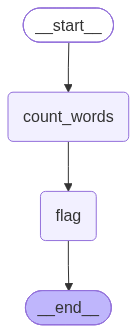

In [8]:
# 그래프 그리기
show_graph(review_app)

In [9]:
result_short = review_app.invoke({"document_text": "짧은 문서입니다", "word_count": 0, "flagged": False})
result_long = review_app.invoke({"document_text": "이 문서는 여러 문장으로 이루어진 상당히 긴 외부 공개용 보고서입니다", "word_count": 0, "flagged": False})

print("result_short:", result_short)
print("result_long:", result_long)

result_short: {'document_text': '짧은 문서입니다', 'word_count': 2, 'flagged': False}
result_long: {'document_text': '이 문서는 여러 문장으로 이루어진 상당히 긴 외부 공개용 보고서입니다', 'word_count': 10, 'flagged': True}


In [10]:

assert result_short["word_count"] == 2
assert result_long["word_count"] == 10
print("result_short flagged:", result_short["flagged"])
print("result_long flagged:", result_long["flagged"])

result_short flagged: False
result_long flagged: True


**관찰**: `result_long`을 만들 때 `result_short`의 State는 전혀 참조되지
않는다. State는 해당 `invoke()` 호출에만 속하며, 다음 실행으로 자동
이어지지 않는다. 8.1에서는 Checkpointer를 연결해 같은 `thread_id`의 State를
단기 기억으로 이어가는 방법을 확인한다.

### 7.4 Long-Term Memory 데이터 구조

실습 편의를 위해 실제 시각 대신 정수로 증가하는 가상 시계(`CURRENT_TICK`)를
사용한다. `advance_time()`으로 시간을 흐르게 할 수 있다.

In [11]:
CURRENT_TICK = 0


def advance_time(days: int) -> None:
    global CURRENT_TICK
    CURRENT_TICK += days


class MemoryRecord(TypedDict):
    key: str
    value: str
    category: str
    created_at: int
    updated_at: int
    expires_at: int | None


MEMORY_STORE: dict[str, list[MemoryRecord]] = {}

### 7.5 확인된 사실 저장

대화 중 확인된 사실을 Memory에 저장한다.

In [12]:
def save_fact(user_id: str, key: str, value: str, category: str = "fact", ttl_days: int | None = None) -> MemoryRecord:
    """새 Memory 레코드를 만들어 MEMORY_STORE에 추가한다."""
    record: MemoryRecord = {
        "key": key,
        "value": value,
        "category": category,
        "created_at": CURRENT_TICK,
        "updated_at": CURRENT_TICK,
        # TTL은 보관 기간이므로 현재 시각에 더해 절대 만료 시각으로 저장한다.
        "expires_at": (CURRENT_TICK + ttl_days) if ttl_days is not None else None,
    }
    MEMORY_STORE.setdefault(user_id, []).append(record)
    return record


fact_record = save_fact("u1", "부서", "개발팀")
print(fact_record)

{'key': '부서', 'value': '개발팀', 'category': 'fact', 'created_at': 0, 'updated_at': 0, 'expires_at': None}


### 7.6 사용자 선호 저장

선호는 사실과 같은 저장 방식을 쓰되 `category="preference"`로 구분한다.

In [13]:
def save_preference(user_id: str, key: str, value: str) -> MemoryRecord:
    """사용자 선호를 category="preference"로 저장한다."""
    return save_fact(user_id, key, value, category="preference")


preference_record = save_preference("u1", "선호_커뮤니케이션", "이메일")
print(preference_record)

{'key': '선호_커뮤니케이션', 'value': '이메일', 'category': 'preference', 'created_at': 0, 'updated_at': 0, 'expires_at': None}


### 7.7 Memory 검색

**TODO**: `search_memory()`를 작성한다.

- `MEMORY_STORE`에서 `user_id`에 해당하는 레코드 목록을 가져온다(없으면
  빈 리스트).
- `key` 또는 `value`에 `keyword`가 포함된 레코드만 리스트로 반환한다.

In [14]:
def search_memory(user_id: str, keyword: str) -> list[MemoryRecord]:
    """key 또는 value에 keyword가 포함된 Memory 레코드를 검색한다."""
    records = MEMORY_STORE.get(user_id, [])
    return [
        r for r in records
        # 아직 물리적으로 삭제하지 않았어도 만료된 레코드는 검색 결과에서 제외한다.
        if (r["expires_at"] is None or r["expires_at"] > CURRENT_TICK)
        and (keyword in r["key"] or keyword in r["value"])
    ]


assert len(search_memory("u1", "부서")) == 1
assert search_memory("u1", "부서")[0]["value"] == "개발팀"
assert search_memory("u1", "존재하지않는키워드") == []
print("search_memory 동작 확인 완료")

search_memory 동작 확인 완료


### 7.8 Memory 삭제 또는 만료 [선택: lifecycle 심화]

In [15]:
def expire_memory(user_id: str) -> list[MemoryRecord]:
    """만료 시각이 지난 레코드를 MEMORY_STORE에서 제거하고, 제거된 레코드를 반환한다."""
    records = MEMORY_STORE.get(user_id, [])
    # 한 번 순회하며 유지할 레코드와 제거할 레코드를 분리한다.
    active, expired = [], []
    for r in records:
        if r["expires_at"] is not None and r["expires_at"] <= CURRENT_TICK:
            expired.append(r)
        else:
            active.append(r)
    MEMORY_STORE[user_id] = active
    return expired


def forget_memory(user_id: str, key: str) -> bool:
    """key와 일치하는 레코드를 명시적으로 삭제한다. 삭제했으면 True."""
    records = MEMORY_STORE.get(user_id, [])
    remaining = [r for r in records if r["key"] != key]
    deleted = len(remaining) != len(records)
    MEMORY_STORE[user_id] = remaining
    return deleted


save_fact("u1", "임시_초대코드", "ABC123", ttl_days=3)
advance_time(5)
expired_records = expire_memory("u1")
print(f"만료되어 제거된 레코드: {expired_records}")
print(f"남은 레코드 수: {len(MEMORY_STORE['u1'])}")

만료되어 제거된 레코드: [{'key': '임시_초대코드', 'value': 'ABC123', 'category': 'fact', 'created_at': 0, 'updated_at': 0, 'expires_at': 3}]
남은 레코드 수: 2


## 8. LangGraph Memory API로 연결 [필수]

Python 딕셔너리로 확인한 개념을 LangGraph의 공식 구성요소로 옮긴다.

| 기억 범위 | LangGraph 구성 | 식별 기준 |
|---|---|---|
| 단기 기억 | Graph State + `InMemorySaver` | `thread_id` |
| 장기 기억 | `InMemoryStore` | namespace + key |

`InMemorySaver`와 `InMemoryStore`는 학습·테스트용 메모리 구현이다. 운영에서는
SQLite, PostgreSQL, Redis 같은 영속 backend를 사용한다.

### 8.1 단기 기억: State + Checkpointer + thread_id

같은 `thread_id`로 다시 호출하면 Checkpointer가 이전 `MessagesState`를 불러온다.
다른 `thread_id`는 독립적인 대화 State에서 시작한다.

In [16]:
def count_thread_turns_node(state: MessagesState) -> dict:
    human_count = sum(isinstance(message, HumanMessage) for message in state["messages"])
    return {
        # MessagesState의 reducer가 이 새 메시지를 기존 thread 기록 뒤에 누적한다.
        "messages": [AIMessage(content=f"이 thread의 사용자 메시지는 {human_count}개입니다.")]
    }


short_term_builder = StateGraph(MessagesState)
short_term_builder.add_node("count_turns", count_thread_turns_node)
short_term_builder.add_edge(START, "count_turns")
short_term_builder.add_edge("count_turns", END)
# Checkpointer는 configurable.thread_id를 키로 각 대화의 State를 분리해 저장한다.
short_term_graph = short_term_builder.compile(checkpointer=InMemorySaver())

thread_a = {"configurable": {"thread_id": "thread-A"}}
thread_b = {"configurable": {"thread_id": "thread-B"}}
short_term_graph.invoke({"messages": [HumanMessage(content="첫 번째 질문")]}, thread_a)
thread_a_second = short_term_graph.invoke(
    {"messages": [HumanMessage(content="두 번째 질문")]}, thread_a
)
thread_b_first = short_term_graph.invoke(
    {"messages": [HumanMessage(content="새 대화 질문")]}, thread_b
)
print("thread-A:", thread_a_second["messages"][-1].content)
print("thread-B:", thread_b_first["messages"][-1].content)

thread-A: 이 thread의 사용자 메시지는 2개입니다.
thread-B: 이 thread의 사용자 메시지는 1개입니다.


### 8.2 장기 기억: Store + namespace

장기 기억은 특정 대화 thread가 아니라 사용자나 애플리케이션 범위에 속한다.
namespace를 `("users", user_id, "memories")`처럼 구성하면 사용자별 기억을
분리하고, 서로 다른 thread에서도 같은 사용자 기억을 조회할 수 있다.

In [17]:
long_term_store = InMemoryStore()
# namespace에 user_id를 포함해 서로 다른 사용자의 장기 기억이 섞이지 않게 한다.
u1_namespace = ("users", "u1", "memories")
u2_namespace = ("users", "u2", "memories")
long_term_store.put(
    u1_namespace,
    "communication_preference",
    {"value": "이메일", "category": "preference"},
)
print("u1 memories:", [item.value for item in long_term_store.search(u1_namespace)])
print("u2 memories:", [item.value for item in long_term_store.search(u2_namespace)])

u1 memories: [{'value': '이메일', 'category': 'preference'}]
u2 memories: []


### 8.3 Checkpointer와 Store를 하나의 Graph에서 사용

`Runtime`은 호출 시 전달한 사용자 Context와 Graph에 연결된 Store를 Node에
주입한다. 다음 예제는 `thread-C`에서 저장한 사용자 기억을 같은 사용자의
새로운 `thread-D`에서 다시 조회한다.

In [18]:
@dataclass
class UserContext:
    user_id: str


class MemoryGraphState(MessagesState):
    remember: str


def memory_bridge_node(
    state: MemoryGraphState,
    runtime: Runtime[UserContext],
) -> dict:
    # thread_id가 아닌 user_id namespace를 사용하므로 다른 thread에서도 같은 기억을 찾는다.
    namespace = ("users", runtime.context.user_id, "memories")
    if state.get("remember"):
        runtime.store.put(
            namespace,
            "latest_preference",
            {"value": state["remember"], "category": "preference"},
        )
    memories = runtime.store.search(namespace)
    summary = ", ".join(item.value["value"] for item in memories) or "저장된 기억 없음"
    return {
        "messages": [AIMessage(content=f"사용자 장기 기억: {summary}")],
        # 입력 필드를 비워 Checkpoint 재사용 시 같은 기억이 반복 저장되는 것을 막는다.
        "remember": "",
    }


memory_builder = StateGraph(MemoryGraphState, context_schema=UserContext)
memory_builder.add_node("memory", memory_bridge_node)
memory_builder.add_edge(START, "memory")
memory_builder.add_edge("memory", END)
memory_graph = memory_builder.compile(
    checkpointer=InMemorySaver(),
    store=long_term_store,
)

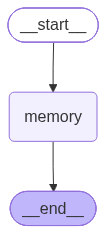

In [19]:
# 시각화는 네트워크 환경에 따라 실패할 수 있으므로 선택적으로 실행한다.
show_graph(memory_graph)

In [20]:
memory_graph.invoke(
    {"messages": [HumanMessage(content="이 선호를 기억해줘")], "remember": "간결한 답변"},
    {"configurable": {"thread_id": "thread-C"}},
    context=UserContext(user_id="u1"),
)

{'messages': [HumanMessage(content='이 선호를 기억해줘', additional_kwargs={}, response_metadata={}, id='9d107a86-1a60-43cc-b58a-a45968d9b946'),
  AIMessage(content='사용자 장기 기억: 이메일, 간결한 답변', additional_kwargs={}, response_metadata={}, id='8dab2def-d824-47c9-ba82-473ec942a4b4', tool_calls=[], invalid_tool_calls=[])],
 'remember': ''}

In [21]:
cross_thread_result = memory_graph.invoke(
    {"messages": [HumanMessage(content="내 선호를 알려줘")], "remember": ""},
    {"configurable": {"thread_id": "thread-D"}},
    context=UserContext(user_id="u1"),
)

In [22]:
other_user_result = memory_graph.invoke(
    {"messages": [HumanMessage(content="내 선호를 알려줘")], "remember": ""},
    {"configurable": {"thread_id": "thread-E"}},
    context=UserContext(user_id="u2"),
)


In [23]:
print("같은 사용자·다른 thread:", cross_thread_result["messages"][-1].content)
print("다른 사용자:", other_user_result["messages"][-1].content)

같은 사용자·다른 thread: 사용자 장기 기억: 이메일, 간결한 답변
다른 사용자: 사용자 장기 기억: 저장된 기억 없음


## 9. 실행 결과 관찰

Thread 대화 기록(Short-Term)에서 만든 Context와, Memory(Long-Term)에서
검색한 결과를 함께 사용하는 흐름을 확인한다.

In [24]:
relevant_memory = search_memory("u1", "선호")
memory_snippet = "; ".join(f"{r['key']}={r['value']}" for r in relevant_memory)

final_context = build_context("thread-1", "당신은 문서 검토를 돕는 Assistant입니다.", max_turns=4)
# 검색된 Memory를 System 메시지로 주입해 현재 요청의 Context에만 선택적으로 사용한다.
final_context.append({"role": "system", "content": f"참고할 사용자 정보: {memory_snippet}"})

prompt_text = "\n".join(f"[{m['role']}] {m['content']}" for m in final_context)
response = call_llm(prompt_text)

print(f"Context 메시지 수: {len(final_context)}")
print(f"Memory에서 가져온 정보: {memory_snippet}")
print(f"응답: {response}")

Context 메시지 수: 5
Memory에서 가져온 정보: 선호_커뮤니케이션=이메일
응답: 외부 고객용 문서인 점을 고려하여 다음 사항들을 점검했습니다:

1. **언어 및 표현**  
   - 전문 용어가 과도하게 사용되지는 않았는지, 고객이 이해하기 쉬운 표현인지 확인했습니다.  
   - 존댓말과 예의 바른 표현이 일관되게 사용되었는지 점검했습니다.

2. **구성 및 가독성**  
   - 문서가 논리적으로 잘 구성되어 있는지, 목차나 제목이 명확한지 확인했습니다.  
   - 문단이 너무 길지 않고 적절히 나누어져 있어 읽기 편한지 검토했습니다.

3. **오탈자 및 문법**  
   - 맞춤법, 띄어쓰기, 문법 오류가 없는지 꼼꼼히 확인했습니다.

4. **연락처 및 추가 정보**  
   - 고객이 문의할 수 있는 연락처(이메일 등)가 명확히 기재되어 있는지 확인했습니다.  
   - 필요 시, 이메일로 문의할 수 있다는 안내 문구가 포함되어 있는지 점검했습니다.

5. **디자인 및 형식**  
   - 문서의 폰트, 색상, 여백 등이 전문적이고 깔끔한지 확인했습니다.  
   - PDF 등 외부 배포에 적합한 형식인지 검토했습니다.

추가로, 이메일로 전달할 때 첨부파일 이름과 이메일 본문 내용도 고객이 이해하기 쉽도록 작성하는 것이 좋습니다. 문서 원본을 제공해주시면 구체적인 수정 사항을 제안해 드릴 수 있습니다.


**결과 해석**: 최종 Context는 Thread 대화 기록 전체가 아니라 최근 4턴과,
Memory에서 검색한 관련 정보 한 줄만 포함한다. 대화가 아무리 길어져도
Context 크기는 `max_turns`와 검색된 Memory 항목 수에 따라 제한된다.

## 10. 실패 실험 [필수: 13절 테스트에 필요]: 선호가 바뀔 때마다 새 레코드로 저장하기

사용자의 선호가 바뀔 때마다 `update_memory()` 없이 `save_fact()`만
반복하면 어떤 문제가 생기는지 확인한다.

In [25]:
save_fact("u2", "선호_커뮤니케이션", "이메일", category="preference")
advance_time(1)
save_fact("u2", "선호_커뮤니케이션", "슬랙", category="preference")

conflicting_results = search_memory("u2", "선호_커뮤니케이션")
print(f"검색된 레코드 수: {len(conflicting_results)}")
for r in conflicting_results:
    print(f"  value={r['value']}, updated_at={r['updated_at']}")

검색된 레코드 수: 2
  value=이메일, updated_at=5
  value=슬랙, updated_at=6


**원인 분석 질문**

- `search_memory("u2", "선호_커뮤니케이션")`은 왜 레코드를 2개 반환하는가?
- 둘 중 어느 것이 "현재" 선호인지 이 결과만으로 알 수 있는가?
- 이런 방식으로 모든 대화의 확인된 정보를 매번 새 레코드로 저장하면,
  Memory 저장소와 검색 결과는 시간이 지날수록 어떻게 되는가?
- Token 비용 관점에서, 검색된 모든 Memory 레코드를 그대로 Context에
  포함시킨다면 어떤 문제가 생기는가?

## 11. 오류 수정 실습 [필수: 13절 테스트에 필요]

같은 `key`에 값이 여러 개 쌓였다면 최신 레코드 하나를 남기고 중복을 제거해야 한다.

**TODO**: `update_memory()`를 작성한다.

- 같은 `key`의 레코드가 없으면 `False`를 반환한다.
- 있으면 가장 최근 레코드의 값과 `updated_at`을 갱신한다.
- 나머지 중복 레코드를 제거하고 `True`를 반환한다.


In [26]:
def update_memory(user_id: str, key: str, new_value: str) -> bool:
    """같은 key의 중복 레코드를 하나로 합치면서 최신 값으로 갱신한다."""
    records = MEMORY_STORE.get(user_id, [])
    matches = [r for r in records if r["key"] == key]
    if not matches:
        return False

    # 중복 중 가장 최근 레코드를 갱신 대상으로 삼고 나머지는 제거한다.
    target = max(matches, key=lambda r: r["updated_at"])
    target["value"] = new_value
    target["updated_at"] = CURRENT_TICK
    MEMORY_STORE[user_id] = [r for r in records if r["key"] != key] + [target]
    return True


assert update_memory("u1", "존재하지않는키", "x") is False
assert update_memory("u2", "선호_커뮤니케이션", "슬랙") is True
print("update_memory 동작 확인 완료")


update_memory 동작 확인 완료


**수정 결과 재검증**: 충돌이 있던 `u2`를 다시 검색하면 레코드가 정확히 1개이고,
값은 최신 선호인 `"슬랙"`이어야 한다.


In [27]:
u2_fixed_results = search_memory("u2", "선호_커뮤니케이션")
assert len(u2_fixed_results) == 1
assert u2_fixed_results[0]["value"] == "슬랙"
print(f"재검증 통과: {u2_fixed_results}")


재검증 통과: [{'key': '선호_커뮤니케이션', 'value': '슬랙', 'category': 'preference', 'created_at': 6, 'updated_at': 6, 'expires_at': None}]


## 12. 도전 과제

1. `build_context()`에 Memory 검색 결과를 포함하되, 검색된 항목이 3개를
   넘으면 가장 최근에 갱신된 것부터 3개만 포함하도록 확장해본다.
2. `MemoryRecord`에 `access_count` 필드를 추가하고, `search_memory()`가
   호출될 때마다 값을 1씩 늘려 "자주 조회되는 Memory"를 구분해본다.
3. `expire_memory()`를 모든 사용자에 대해 한 번에 실행하는
   `expire_all_memory()`를 작성해본다.

## 13. 테스트

**테스트 유형: 로컬 통합 테스트 — 결정적, 외부 API 호출 없음**

Context 구성, Graph State, Checkpointer와 Store의 thread·namespace 분리를 함께 검증한다.

In [28]:
assert len(search_memory("u1", "부서")) == 1
assert search_memory("u1", "존재하지않는키워드") == []

assert update_memory("u1", "존재하지않는키", "x") is False

context_check = build_context("thread-1", "system", max_turns=2)
assert len(context_check) == 3
assert context_check[0]["role"] == "system"

stale_initial_state = {"document_text": "짧음", "word_count": 999, "flagged": True}
state_check = review_app.invoke(stale_initial_state)
assert state_check["word_count"] == 1
assert state_check["flagged"] is False

u2_conflict_check = search_memory("u2", "선호_커뮤니케이션")
assert len(u2_conflict_check) == 1

assert u2_conflict_check[0]["value"] == "슬랙"

memory_record_fields = {"key", "value", "category", "created_at", "updated_at", "expires_at"}
assert set(MemoryRecord.__annotations__.keys()) == memory_record_fields

assert "2개" in thread_a_second["messages"][-1].content
assert "1개" in thread_b_first["messages"][-1].content
assert len(long_term_store.search(u1_namespace)) >= 2
assert long_term_store.search(u2_namespace) == []
assert "간결한 답변" in cross_thread_result["messages"][-1].content
assert "저장된 기억 없음" in other_user_result["messages"][-1].content

print("테스트 통과")

테스트 통과


## 14. 결과 저장

In [29]:
context_state_memory_log = {
    "context_example": {"thread_id": "thread-1", "message_count": len(context_1)},
    "state_example": {
        "result_short": result_short,
        "result_long": result_long,
        "independent": result_short["word_count"] != result_long["word_count"],
    },
    "memory_examples": {
        "u1_final": MEMORY_STORE.get("u1", []),
        "u2_after_deduplication": u2_conflict_check,
    },
    "langgraph_memory_bridge": {
        "thread_a_message_count": len(thread_a_second["messages"]),
        "thread_b_message_count": len(thread_b_first["messages"]),
        "u1_namespace": list(u1_namespace),
        "u1_memories": [item.value for item in long_term_store.search(u1_namespace)],
        "cross_thread_recall": cross_thread_result["messages"][-1].content,
    },
}
saved_path = save_log(context_state_memory_log, OUTPUT_DIR / "logs" / "04-1_context_state_memory_log.json")
print("저장 위치:", saved_path)

저장 위치: E:\agentic_ai_lab\outputs\logs\04-1_context_state_memory_log.json


## 15. 핵심 정리

- Context는 현재 LLM 호출에 포함되는 정보이고 State는 Graph Node가 공유하는
  작업 데이터다.
- `build_context()`처럼 전체 대화 기록이 아니라 필요한 최근 부분만 골라야
  Token 비용을 관리할 수 있다.
- Checkpointer가 없는 State는 다음 호출로 자동 전달되지 않는다. `InMemorySaver`와
  같은 `thread_id`를 사용하면 thread 범위의 단기 기억으로 이어진다.
- `InMemoryStore`는 namespace와 key로 장기 기억을 저장하며, 같은 사용자 namespace를
  사용하는 서로 다른 thread가 기억을 공유할 수 있다.
- 같은 Memory 키의 값이 바뀔 때는 `save_fact()`로 새 레코드를 추가하는
  대신 `update_memory()`로 기존 레코드를 갱신해야 모순된 기억이 쌓이지
  않는다.

## 16. 확인 문제

1. Checkpointer가 없는 State와 Checkpointer가 연결된 State는 다음 `invoke()`에서
   어떻게 다르게 동작하는가?
2. 대화 기록 전체를 매번 Context에 그대로 포함시키면 어떤 문제가 생기는가?
3. 사용자의 선호가 바뀌었을 때 `save_fact()`만 반복 호출하면 어떤 문제가
   생기는가? 이를 방지하려면 어떻게 해야 하는가?
4. `thread_id`와 Store의 namespace는 각각 어떤 범위를 구분하는가?
5. Memory를 "모든 대화 내용을 저장하는 곳"이라고 이해하는 것이 왜 오해인가?